# 🚗 Car Price Prediction — End-to-End Machine Learning Pipeline

Dataset: Car Details v3

Target: selling_price (Regression)

Pipeline: Data Cleaning → EDA → Preprocessing → Model Building → Evaluation → Hyperparameter Tuning → L1/L2 Regularization → Pickle → Gradio Interface

# 📦 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
sns.set_palette('husl')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

print('✅ All libraries imported successfully!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

✅ All libraries imported successfully!
Pandas: 2.2.2 | NumPy: 2.0.2


# 📂 2. Load Dataset

In [2]:
df=pd.read_csv('Car details v3.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
print()
print('Column Names:', df.columns.tolist())
df.head()

Dataset Shape: (8128, 13)
Rows: 8,128 | Columns: 13

Column Names: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [4]:
df.describe(include='all')

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
count,8128,8128.000000,8.128000e+03,8.128000e+03,8128,8128,8128,8128,7907,7907,7913,7906,7907.000000
unique,2058,NaN,NaN,NaN,4,3,2,5,393,121,322,441,NaN
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,NaN
freq,129,NaN,NaN,NaN,4402,6766,7078,5289,225,1017,377,530,NaN
mean,NaN,2013.804011,6.382718e+05,6.981951e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.416719
std,NaN,4.044249,8.062534e+05,5.655055e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959588
min,NaN,1983.000000,2.999900e+04,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,2011.000000,2.549990e+05,3.500000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,2015.000000,4.500000e+05,6.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,2017.000000,6.750000e+05,9.800000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000


# 🧹 3. Data Cleaning

### 3.1 Missing Values Analysis

Missing Values Summary:
           Missing Count  Missing %
torque               222       2.73
seats                221       2.72
engine               221       2.72
mileage              221       2.72
max_power            215       2.65


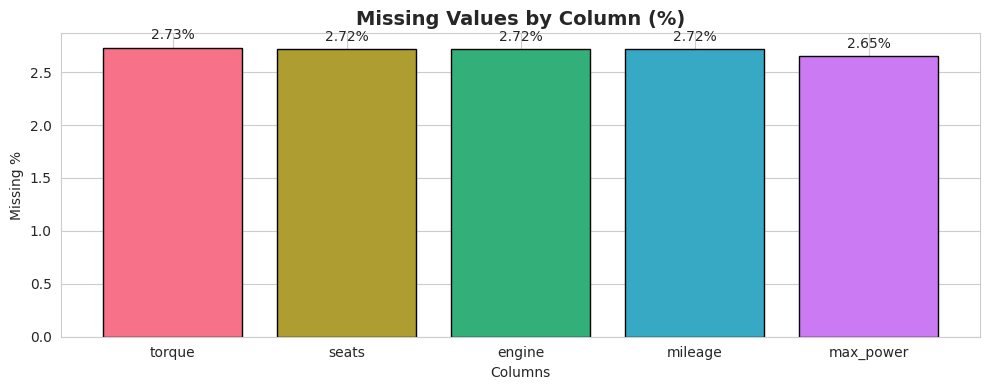

In [5]:
missing=df.isnull().sum()
missing_pct=(missing / len(df)*100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
bars = ax.bar(cols_with_missing.index, cols_with_missing['Missing %'],
              color=sns.color_palette('husl', len(cols_with_missing)), edgecolor='black')
ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Columns')
for bar, val in zip(bars, cols_with_missing['Missing %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

### 3.2 Parse & Clean Numeric-String Columns

In [6]:
def clean_df(df):
    df = df.copy()

    # ── mileage: '23.4 kmpl' or '26.6 km/kg' → float
    df['mileage'] = df['mileage'].str.extract(r'([\d.]+)').astype(float)

    # ── engine: '1248 CC' → float
    df['engine'] = df['engine'].str.extract(r'([\d.]+)').astype(float)

    # ── max_power: '74 bhp' or ' bhp' → float (edge case: blank bhp)
    df['max_power'] = df['max_power'].str.extract(r'([\d.]+)').astype(float)

    # ── torque: too noisy; drop it
    df.drop(columns=['torque'], inplace=True)

    # ── name → brand (first word only; 2058 car names → manageable brands)
    df['brand'] = df['name'].str.split().str[0]
    df.drop(columns=['name'], inplace=True)

    # ── seats: float → int (after fill)
    df['seats'] = df['seats'].fillna(df['seats'].mode()[0])
    df['seats'] = df['seats'].astype(int)

    # ── car_age: more intuitive than raw year
    df['car_age'] = 2026 - df['year']
    df.drop(columns=['year'], inplace=True)

    # ── Fill remaining numeric NaNs with median (robust to outliers)
    for col in ['mileage', 'engine', 'max_power']:
        df[col].fillna(df[col].median(), inplace=True)

    return df

df_clean = clean_df(df)

print('Shape after cleaning:', df_clean.shape)
print('Remaining nulls:')
print(df_clean.isnull().sum())
df_clean.head()

Shape after cleaning: (8128, 12)
Remaining nulls:
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
brand            0
car_age          0
dtype: int64


,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand,car_age
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5,Maruti,12
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5,Skoda,12
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5,Honda,20
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5,Hyundai,16
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5,Maruti,19


### 3.3 Remove Duplicates & Outliers

In [7]:
 #Duplicates
dups=df_clean.duplicated().sum()
print(f'Duplicate rows : {dups}')
df_clean.drop_duplicates(inplace=True)
print(f'Shape after dedup: {df_clean.shape}')

Duplicate rows : 1221
Shape after dedup: (6907, 12)


In [8]:
#IQR-based outlier removal on target + key numeric features
def remove_outliers_iqr(df,cols,multiplier=3.0):
  mask=pd.Series([True]*len(df),index=df.index)
  for col in cols:
    Q1,Q3=df[col].quantile(0.25),df[col].quantile(0.75)
    IQR=Q3-Q1
    mask &=df[col].between(Q1 - multiplier*IQR,Q3 + multiplier*IQR)
  return df[mask]

before=len(df_clean)
df_clean=remove_outliers_iqr(df_clean,['selling_price', 'km_driven', 'max_power'])
df_clean.reset_index(drop=True,inplace=True)
print(f'Rows removed as outliers: {before - len(df_clean)}')
print(f'Final shape : {df_clean.shape}')

Rows removed as outliers: 209
Final shape : (6698, 12)


## 📊 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

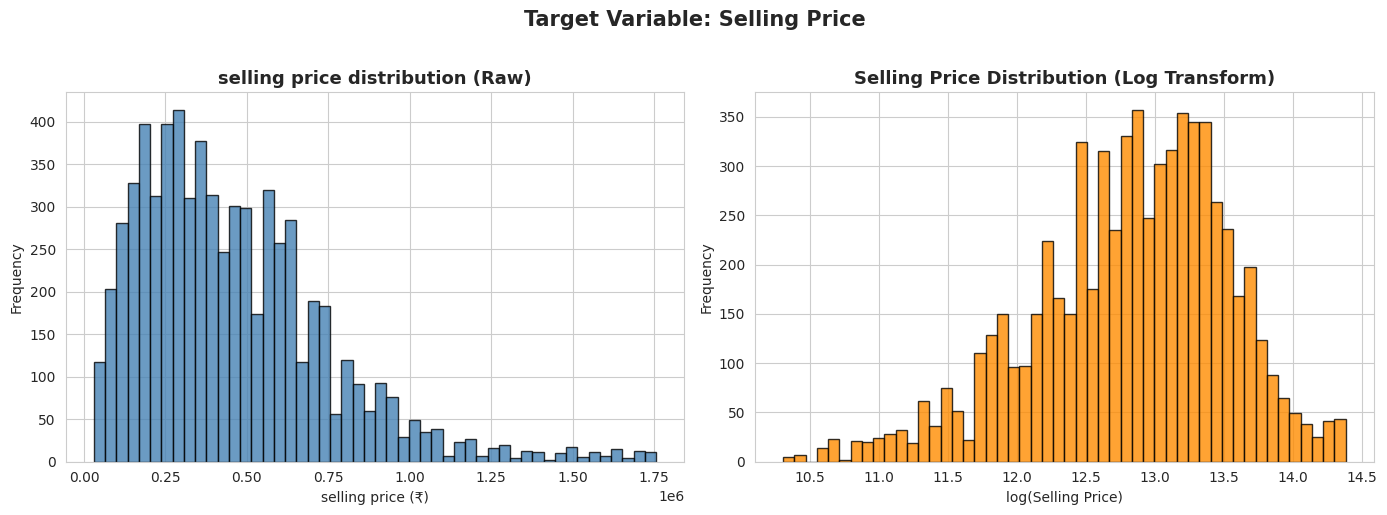

Skewness (raw): 1.296
Skewness (log): -0.563


In [9]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].hist(df_clean['selling_price'],bins=50,color='steelblue',edgecolor='black',alpha=0.8)
axes[0].set_title('selling price distribution (Raw)',fontsize=13,fontweight='bold')
axes[0].set_xlabel('selling price (₹)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df_clean['selling_price']), bins=50, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_title('Selling Price Distribution (Log Transform)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Selling Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: Selling Price', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Skewness (raw): {df_clean["selling_price"].skew():.3f}')
print(f'Skewness (log): {np.log1p(df_clean["selling_price"]).skew():.3f}')

### 4.2 Categorical Feature Analysis

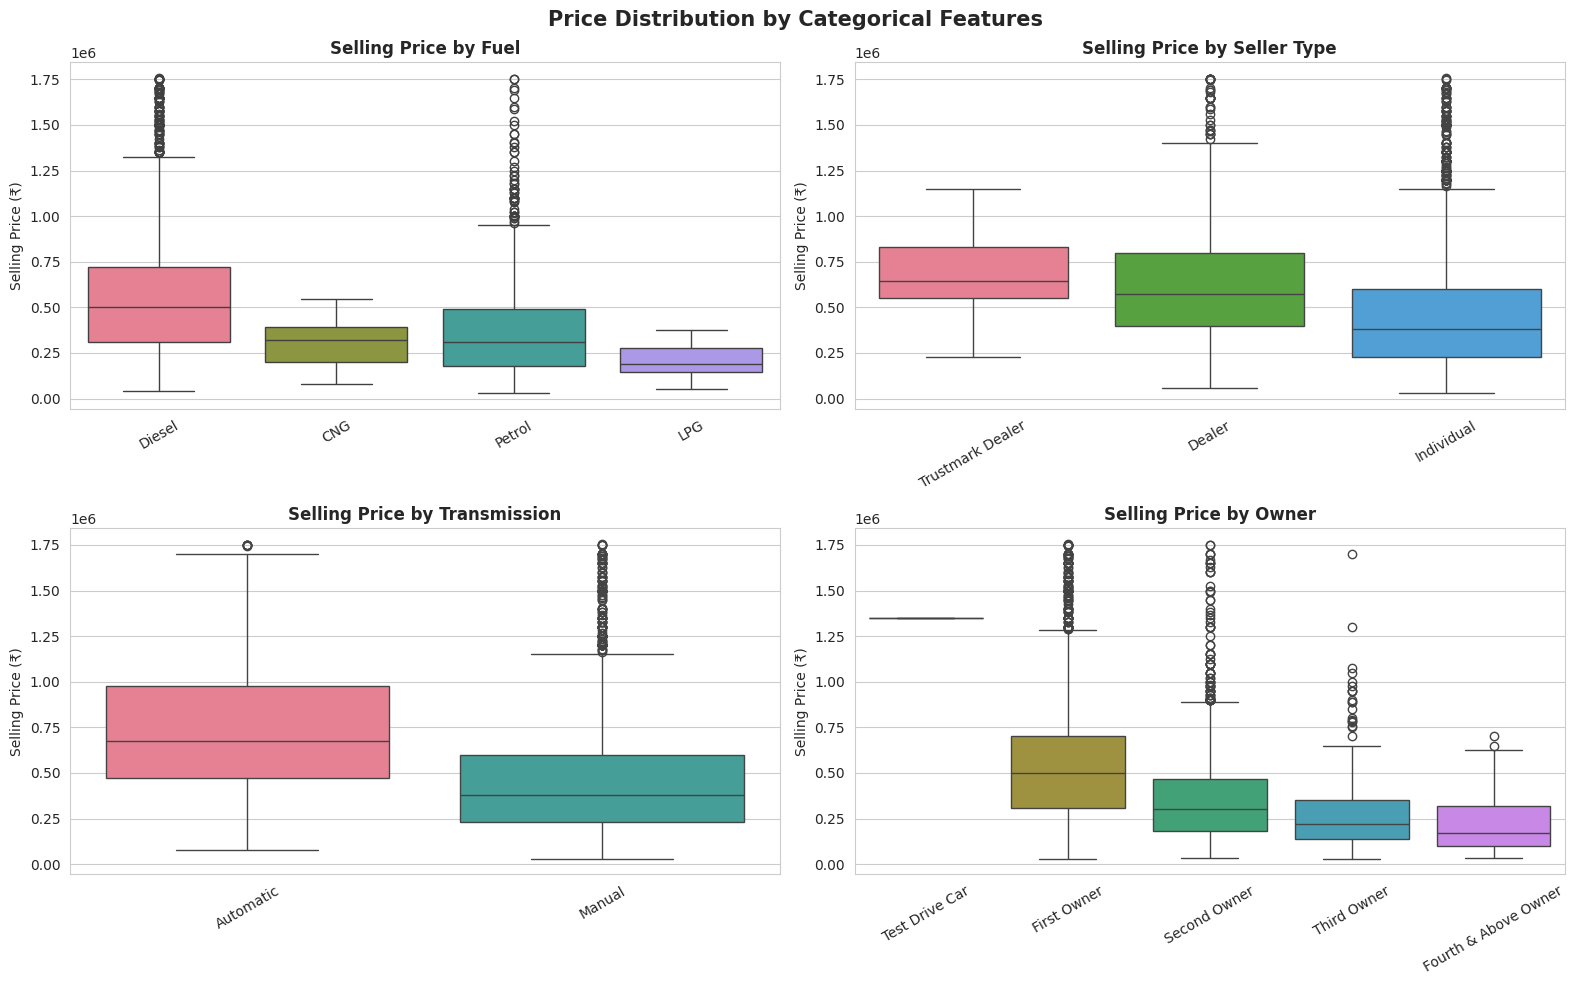

In [10]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    medians = df_clean.groupby(col)['selling_price'].median().sort_values(ascending=False)
    sns.boxplot(data=df_clean, x=col, y='selling_price', order=medians.index, ax=axes[i],
                palette='husl')
    axes[i].set_title(f'Selling Price by {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Selling Price (₹)')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Price Distribution by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Numerical Feature Distributions & Correlations

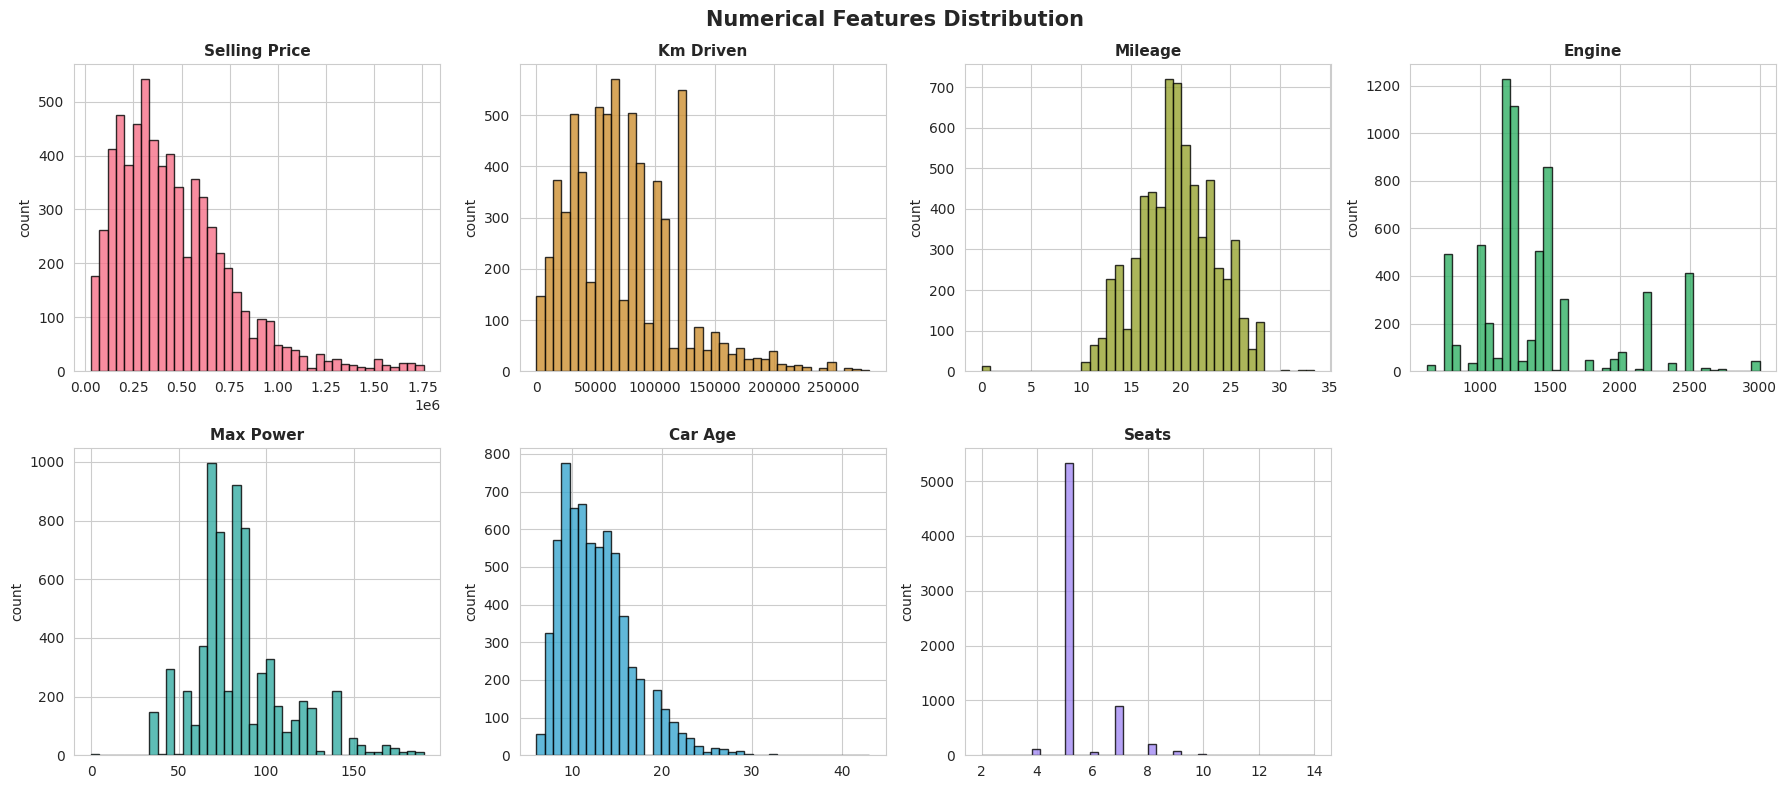

In [11]:
num_cols=['selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'car_age', 'seats']

fig,axes=plt.subplots(2,4,figsize=(18,8))
axes=axes.flatten()

for i,col in enumerate(num_cols):
  axes[i].hist(df_clean[col],bins=40,color=sns.color_palette('husl',8)[i],edgecolor='black',alpha=0.8)
  axes[i].set_title(col.replace('_',' ').title(),fontsize=11,fontweight='bold')
  axes[i].set_ylabel('count')

axes[-1].axis('off')
plt.suptitle('Numerical Features Distribution',fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()

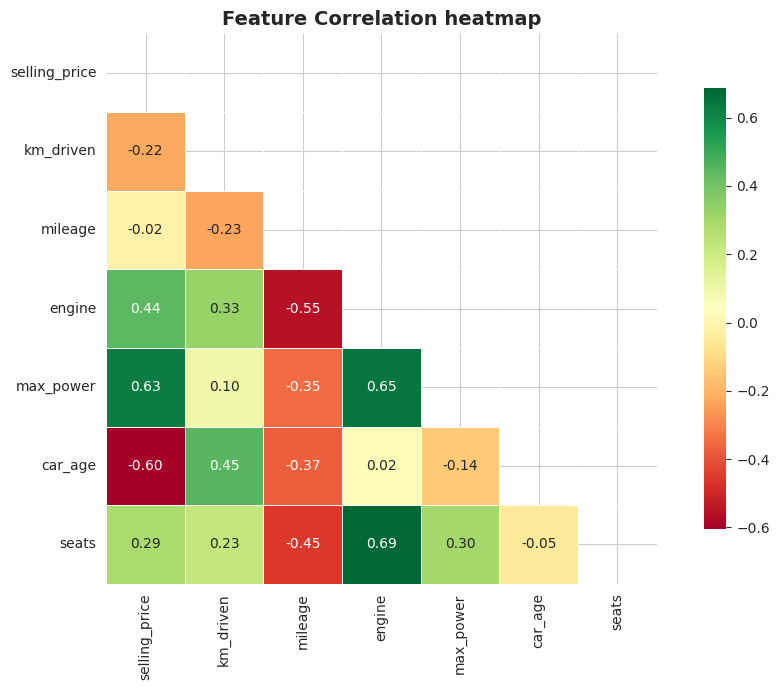

In [12]:
#Correlation Heatmap
corr=df_clean[num_cols].corr()

plt.figure(figsize=(10,7))
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='RdYlGn',linewidths=0.5,square=True,cbar_kws={'shrink':0.8})
plt.title('Feature Correlation heatmap',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

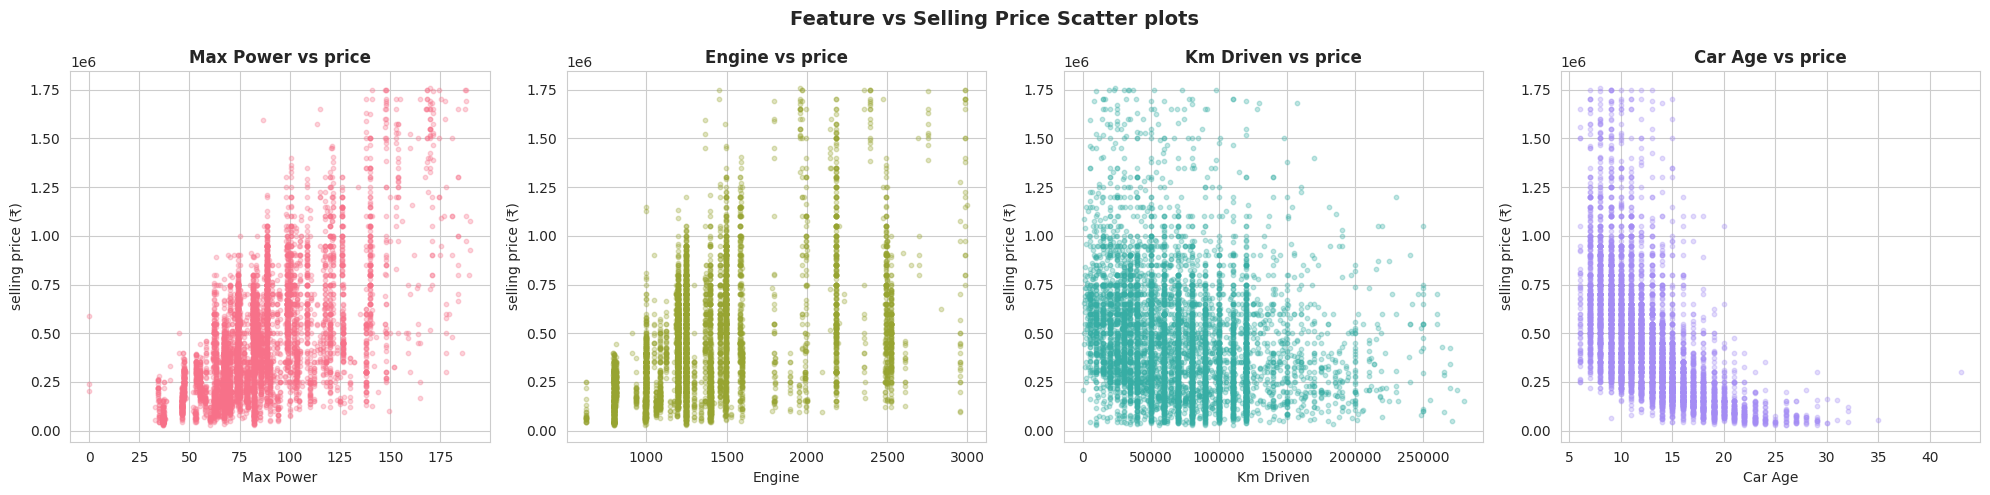

In [13]:
#Scatter plots: Key Features vs selling price

key_feats=['max_power','engine','km_driven','car_age']

fig,axes=plt.subplots(1,4,figsize=(20,5))

for i , feat in enumerate(key_feats):
  axes[i].scatter(df_clean[feat],df_clean['selling_price'],alpha=0.3,s=10,color=sns.color_palette('husl',4)[i])
  axes[i].set_xlabel(feat.replace('_',' ').title())
  axes[i].set_ylabel('selling price (₹)')
  axes[i].set_title(f'{feat.replace("_"," ").title()} vs price',fontweight='bold')
plt.suptitle('Feature vs Selling Price Scatter plots',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Brand Analysis

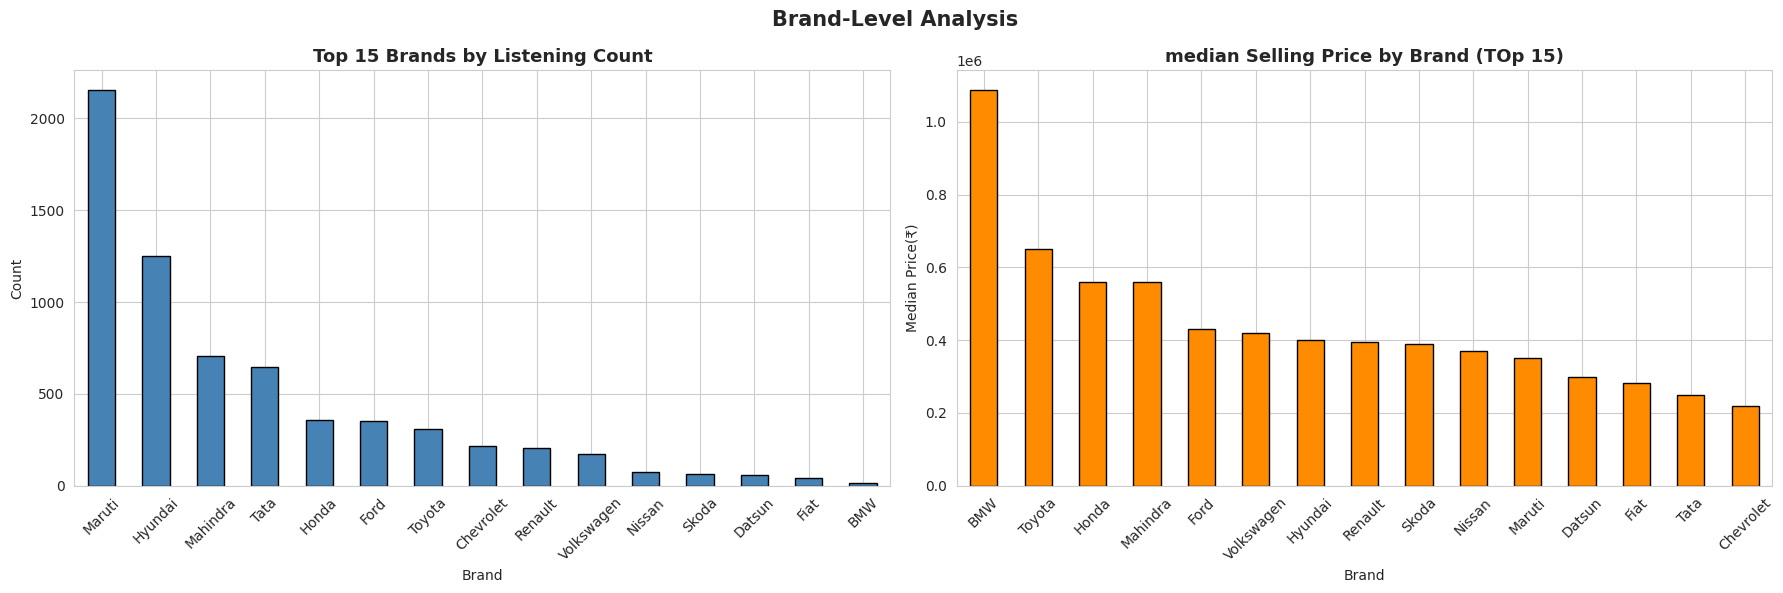

In [14]:
brand_counts=df_clean['brand'].value_counts().head(15)
brand_price =df_clean.groupby('brand')['selling_price'].median().reindex(brand_counts.index)
fig,axes=plt.subplots(1,2,figsize=(18,6))

brand_counts.plot(kind='bar',ax=axes[0],color='steelblue',edgecolor='black')
axes[0].set_title('Top 15 Brands by Listening Count',fontsize=13,fontweight='bold')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x',rotation=45)

brand_price.sort_values(ascending=False).plot(kind='bar',ax=axes[1],color='darkorange',edgecolor='black')
axes[1].set_title('median Selling Price by Brand (TOp 15)',fontsize=13,fontweight='bold')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Median Price(₹)')
axes[1].tick_params(axis='x',rotation=45)

plt.suptitle('Brand-Level Analysis',fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()

### ⚙️ 5. Preprocessing

In [15]:
#Apply log transform to the target (reduces skewness significantly)
df_model=df_clean.copy()
df_model['log_price']=np.log1p(df_model['selling_price'])

#Features & Target
FEATURES=['km_driven', 'fuel', 'seller_type', 'transmission', 'owner',
            'mileage', 'engine', 'max_power', 'seats', 'car_age', 'brand']
TARGET  ='log_price'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Feature matrix shape:{X.shape}')
print(f'Target vector shape:{y.shape}')

Feature matrix shape:(6698, 11)
Target vector shape:(6698,)


In [16]:
#define column types
NUMERIC_COLS=['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'car_age']
CAT_COLS    =['fuel', 'seller_type', 'transmission', 'owner', 'brand']

#ColumnTransformer: impute + scale numerics + OHE categoricals
numeric_pipeline = Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',RobustScaler())])

cat_pipeline=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
                       ('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])

preprocessor= ColumnTransformer(transformers=[('num',numeric_pipeline,NUMERIC_COLS),
                                              ('cat',cat_pipeline,CAT_COLS)])
# Train/Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(f'Training set: {X_train.shape}')
print(f'Test set    :{X_test.shape}')

Training set: (5358, 11)
Test set    :(1340, 11)


### 🏗️ 6. Model Building — Baseline Comparison

In [17]:
def evaluate_pipeline(pipeline,X_train,y_train,X_test,y_test,label='Model'):
  pipeline.fit(X_train,y_train)
  y_pred_log=pipeline.predict(X_test)

  # Convert back from log scale
  y_pred=np.expm1(y_pred_log)
  y_true=np.expm1(y_test)

  mae=mean_absolute_error(y_true,y_pred)
  rmse=np.sqrt(mean_squared_error(y_true,y_pred))
  r2=r2_score(y_true,y_pred)
  mape=mean_absolute_percentage_error(y_true,y_pred)*100

  #Cross-val R² on log scale
  cv_scores=cross_val_score(pipeline,X_train,y_train,cv=5,scoring='r2')

  return{
      'Model':label,'MAE':mae,'RMSE':rmse,
      'R2':r2,'MAPE (%)':mape,
      'CV R2 Mean':cv_scores.mean(), 'CV R2 Std':cv_scores.std()
  }

models= [
    ('Linear Regression',    LinearRegression()),
    ('Ridge (L2)',           Ridge(alpha=1.0)),
    ('Lasso (L1)',           Lasso(alpha=0.001)),
    ('ElasticNet (L1+L2)',   ElasticNet(alpha=0.001, l1_ratio=0.5)),
    ('Decision Tree',        DecisionTreeRegressor(random_state=42)),
    ('Random Forest',        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('Gradient Boosting',    GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

results=[]
trained_pipelines={}

for name, model in models:
    print(f'Training: {name}...', end=' ')
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    metrics = evaluate_pipeline(pipe, X_train, y_train, X_test, y_test, label=name)
    results.append(metrics)
    trained_pipelines[name] = pipe
    print(f'R² = {metrics["R2"]:.4f}')

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('R2', ascending=False)
print('\n📊 Model Comparison:')
results_df.style.format({'MAE': '₹{:,.0f}', 'RMSE': '₹{:,.0f}', 'R2': '{:.4f}',
                          'MAPE (%)': '{:.2f}%', 'CV R2 Mean': '{:.4f}', 'CV R2 Std': '{:.4f}'})

Training: Linear Regression... R² = 0.8498
Training: Ridge (L2)... R² = 0.8507
Training: Lasso (L1)... R² = 0.8466
Training: ElasticNet (L1+L2)... R² = 0.8496
Training: Decision Tree... R² = 0.7919
Training: Random Forest... R² = 0.8814
Training: Gradient Boosting... R² = 0.8695

📊 Model Comparison:


,MAE,RMSE,R2,MAPE (%),CV R2 Mean,CV R2 Std
Model,,,,,,
Random Forest,"₹66,943","₹101,305",0.8814,16.87%,0.8985,0.0045
Gradient Boosting,"₹71,094","₹106,260",0.8695,17.42%,0.8984,0.0023
Ridge (L2),"₹79,736","₹113,683",0.8507,19.83%,0.8701,0.0038
Linear Regression,"₹79,939","₹114,006",0.8498,19.84%,0.8698,0.0041
ElasticNet (L1+L2),"₹79,992","₹114,077",0.8496,19.96%,0.8687,0.0035
Lasso (L1),"₹80,563","₹115,208",0.8466,20.07%,0.8679,0.0034
Decision Tree,"₹86,734","₹134,204",0.7919,22.11%,0.8294,0.0094


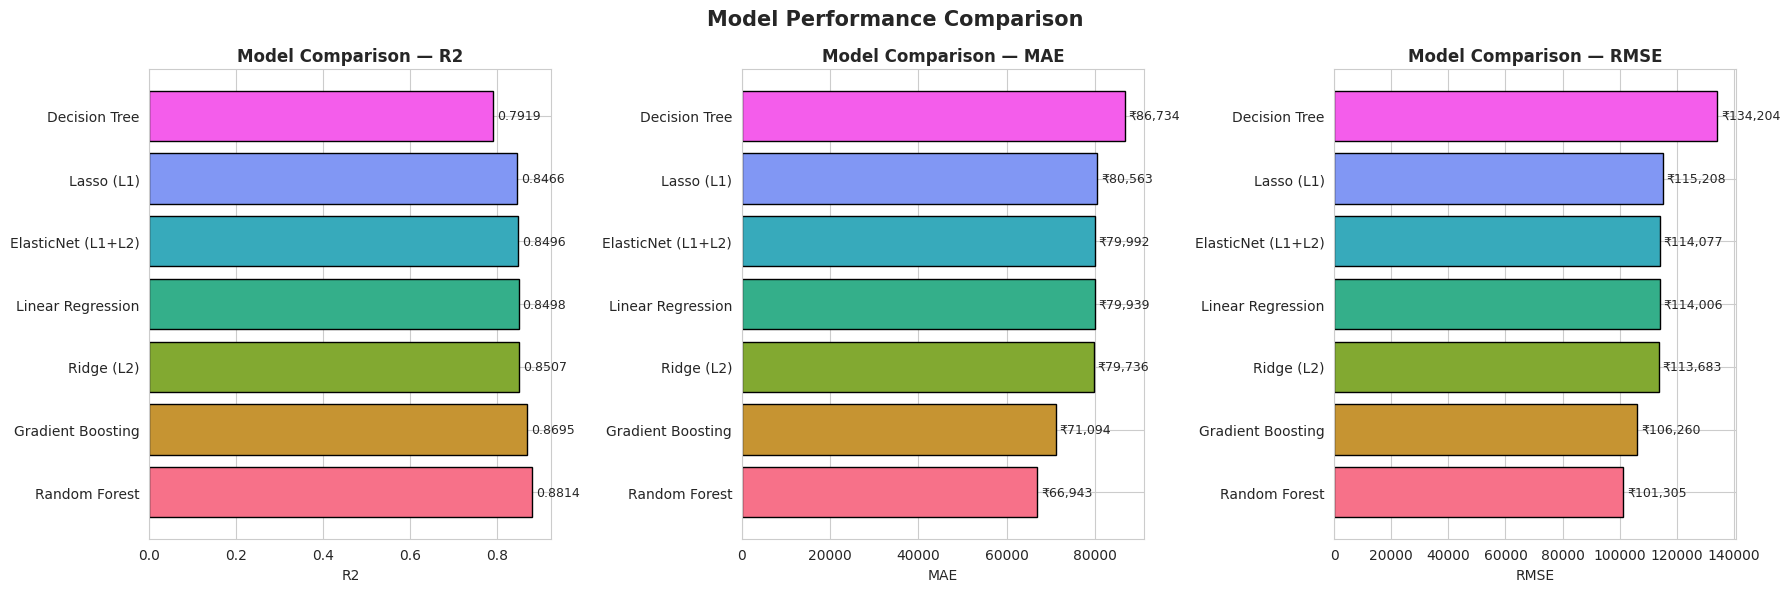

In [18]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['R2', 'MAE', 'RMSE']
colors = sns.color_palette('husl', len(results_df))

for i, metric in enumerate(metrics_to_plot):
    vals = results_df[metric].sort_values(ascending=(metric != 'R2'))
    bars = axes[i].barh(vals.index, vals.values, color=colors, edgecolor='black')
    axes[i].set_title(f'Model Comparison — {metric}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(metric)
    for bar, val in zip(bars, vals.values):
        label = f'{val:.4f}' if metric == 'R2' else f'₹{val:,.0f}'
        axes[i].text(bar.get_width() + max(vals.values) * 0.01, bar.get_y() + bar.get_height() / 2,
                     label, va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔬 7. L1 & L2 Regularization Deep Dive

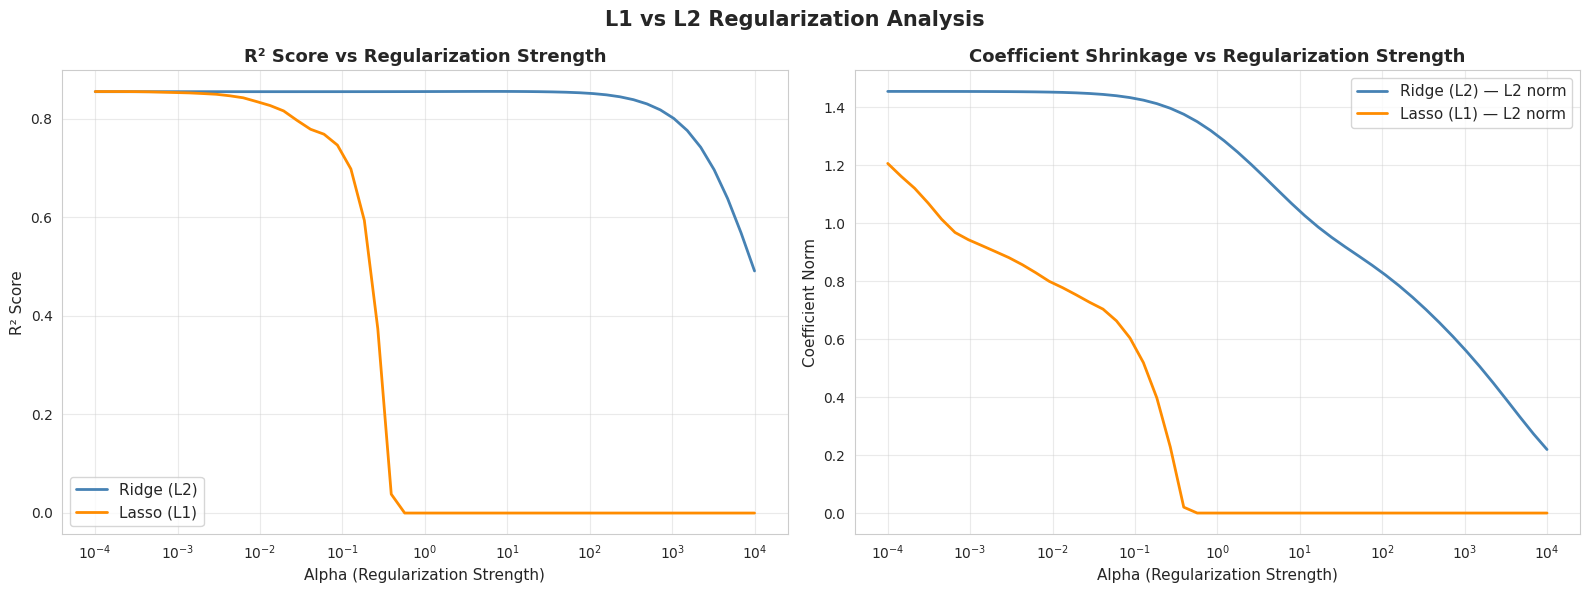

Best Ridge alpha: 5.4287 → R² = 0.8560
Best Lasso alpha: 0.000146 → R² = 0.8557


In [19]:
# Effect of alpha on Ridge (L2) and Lasso (L1)
alphas = np.logspace(-4, 4, 50)

ridge_r2, lasso_r2 = [], []
ridge_coef_norms, lasso_coef_norms = [], []

# Fit preprocessor once
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

for a in alphas:
    # Ridge
    r = Ridge(alpha=a).fit(X_train_prep, y_train)
    ridge_r2.append(r2_score(y_test, r.predict(X_test_prep)))
    ridge_coef_norms.append(np.linalg.norm(r.coef_))

    # Lasso
    l = Lasso(alpha=a, max_iter=5000).fit(X_train_prep, y_train)
    lasso_r2.append(r2_score(y_test, l.predict(X_test_prep)))
    lasso_coef_norms.append(np.linalg.norm(l.coef_))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² vs Alpha
axes[0].semilogx(alphas, ridge_r2, label='Ridge (L2)', color='steelblue', lw=2)
axes[0].semilogx(alphas, lasso_r2, label='Lasso (L1)', color='darkorange', lw=2)
axes[0].set_xlabel('Alpha (Regularization Strength)', fontsize=11)
axes[0].set_ylabel('R² Score', fontsize=11)
axes[0].set_title('R² Score vs Regularization Strength', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)

# Coefficient Norm vs Alpha
axes[1].semilogx(alphas, ridge_coef_norms, label='Ridge (L2) — L2 norm', color='steelblue', lw=2)
axes[1].semilogx(alphas, lasso_coef_norms, label='Lasso (L1) — L2 norm', color='darkorange', lw=2)
axes[1].set_xlabel('Alpha (Regularization Strength)', fontsize=11)
axes[1].set_ylabel('Coefficient Norm', fontsize=11)
axes[1].set_title('Coefficient Shrinkage vs Regularization Strength', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.4)

plt.suptitle('L1 vs L2 Regularization Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

best_ridge_alpha = alphas[np.argmax(ridge_r2)]
best_lasso_alpha = alphas[np.argmax(lasso_r2)]
print(f'Best Ridge alpha: {best_ridge_alpha:.4f} → R² = {max(ridge_r2):.4f}')
print(f'Best Lasso alpha: {best_lasso_alpha:.6f} → R² = {max(lasso_r2):.4f}')

Total features     : 48
Non-zero (Lasso)   : 35
Zeroed out (sparse): 13


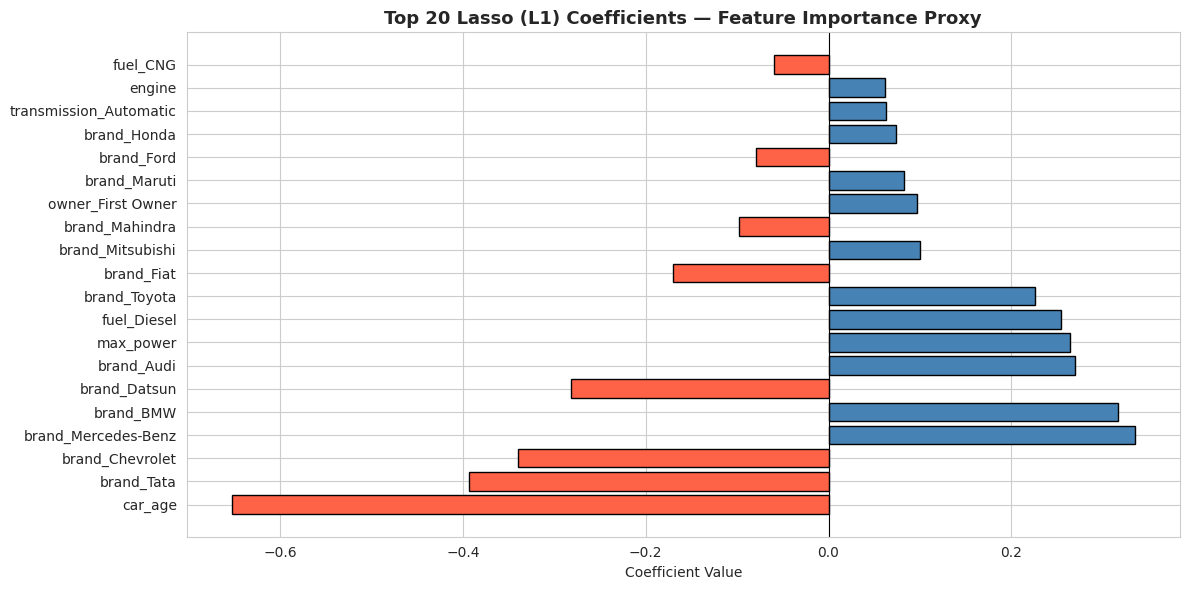

In [20]:
# Lasso Feature Sparsity
lasso_model = Lasso(alpha=best_lasso_alpha, max_iter=5000)
lasso_model.fit(X_train_prep, y_train)

cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(CAT_COLS).tolist()
all_feature_names  = NUMERIC_COLS + cat_feature_names

nonzero_mask = lasso_model.coef_ != 0
print(f'Total features     : {len(lasso_model.coef_)}')
print(f'Non-zero (Lasso)   : {nonzero_mask.sum()}')
print(f'Zeroed out (sparse): {(~nonzero_mask).sum()}')

# Top non-zero coefficients
coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': lasso_model.coef_})
coef_df = coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(12, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient'].head(20)]
plt.barh(coef_df['Feature'].head(20), coef_df['Coefficient'].head(20), color=colors, edgecolor='black')
plt.title('Top 20 Lasso (L1) Coefficients — Feature Importance Proxy', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

### 📈 8. Model Evaluation — Best Model Deep Dive

In [21]:
# Best model (likely Random Forest or Gradient Boosting)
best_name = results_df.index[0]
best_pipe = trained_pipelines[best_name]

print(f'🏆 Best Model: {best_name}')
print(f'   R²   : {results_df.loc[best_name, "R2"]:.4f}')
print(f'   MAE  : ₹{results_df.loc[best_name, "MAE"]:,.0f}')
print(f'   RMSE : ₹{results_df.loc[best_name, "RMSE"]:,.0f}')

🏆 Best Model: Random Forest
   R²   : 0.8814
   MAE  : ₹66,943
   RMSE : ₹101,305


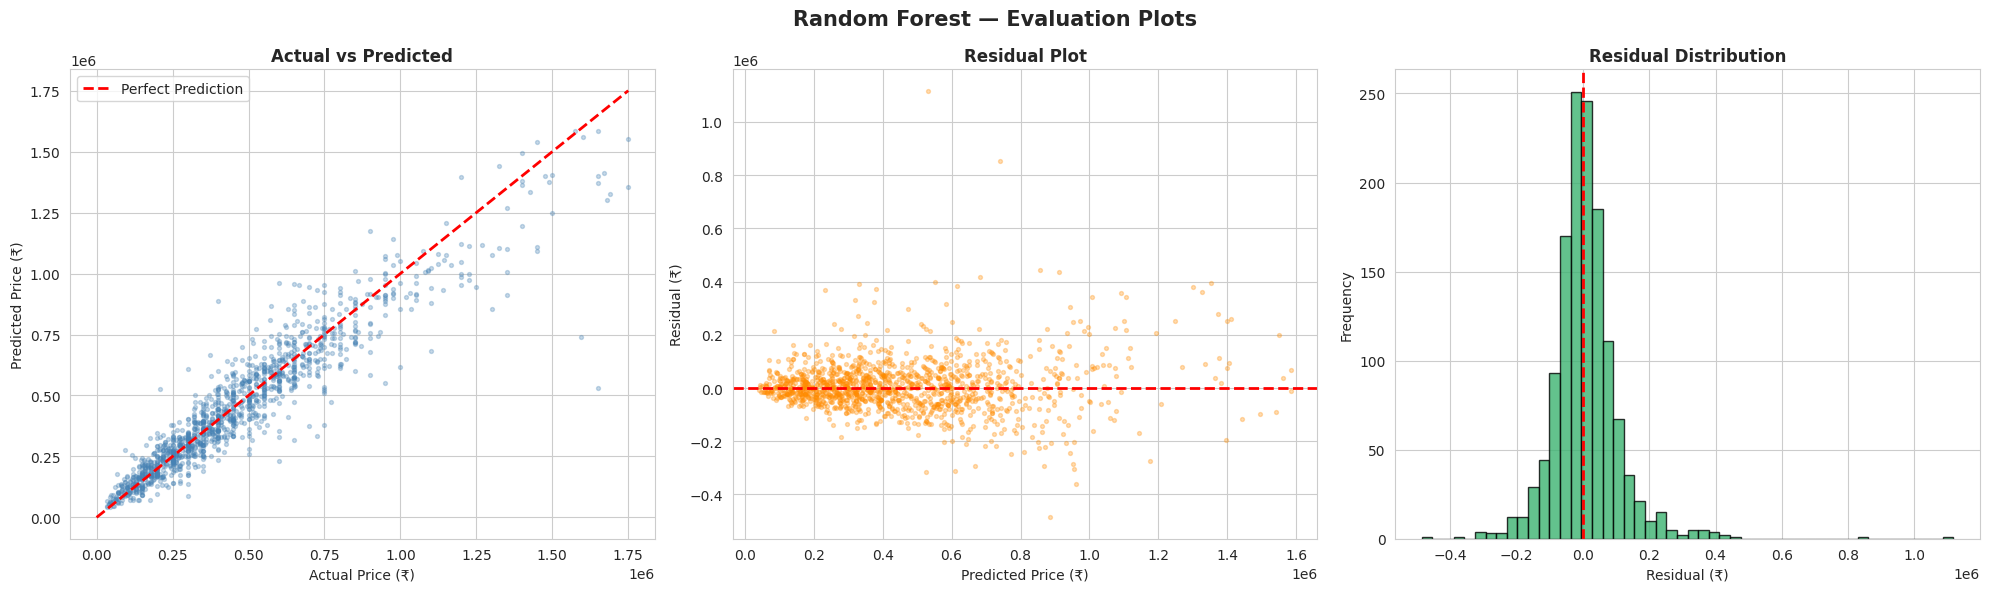

In [22]:
# Actual vs Predicted Plot
y_pred_log = best_pipe.predict(X_test)
y_pred_raw = np.expm1(y_pred_log)
y_true_raw = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Actual vs Predicted
axes[0].scatter(y_true_raw, y_pred_raw, alpha=0.3, s=8, color='steelblue')
maxval = max(y_true_raw.max(), y_pred_raw.max())
axes[0].plot([0, maxval], [0, maxval], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (₹)')
axes[0].set_ylabel('Predicted Price (₹)')
axes[0].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_true_raw - y_pred_raw
axes[1].scatter(y_pred_raw, residuals, alpha=0.3, s=8, color='darkorange')
axes[1].axhline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted Price (₹)')
axes[1].set_ylabel('Residual (₹)')
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')

# Residual Distribution
axes[2].hist(residuals, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].axvline(0, color='red', lw=2, linestyle='--')
axes[2].set_xlabel('Residual (₹)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution', fontsize=12, fontweight='bold')

plt.suptitle(f'{best_name} — Evaluation Plots', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

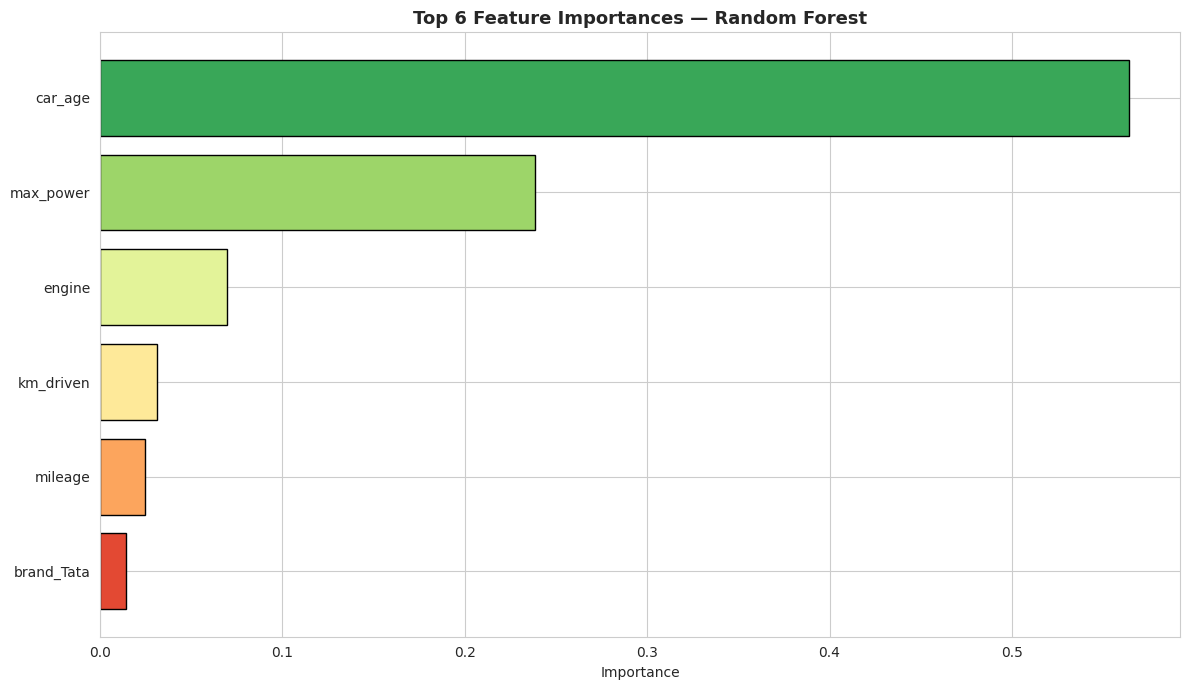

In [23]:
# Feature Importance (Random Forest / GB)
model_step = best_pipe.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    cat_names = best_pipe.named_steps['prep'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(CAT_COLS)
    feat_names = NUMERIC_COLS + list(cat_names)
    importances = model_step.feature_importances_

    feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(6)

    plt.figure(figsize=(12, 7))
    colors = sns.color_palette('RdYlGn_r', len(feat_imp_df))
    plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors, edgecolor='black')
    plt.title(f'Top 6 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Feature importances not available for this model type.')

5-Fold Cross-Validation R² for Random Forest:
  Fold 1: 0.8919
  Fold 2: 0.9018
  Fold 3: 0.9025
  Fold 4: 0.8984
  Fold 5: 0.8983
  Mean : 0.8986 ± 0.0038


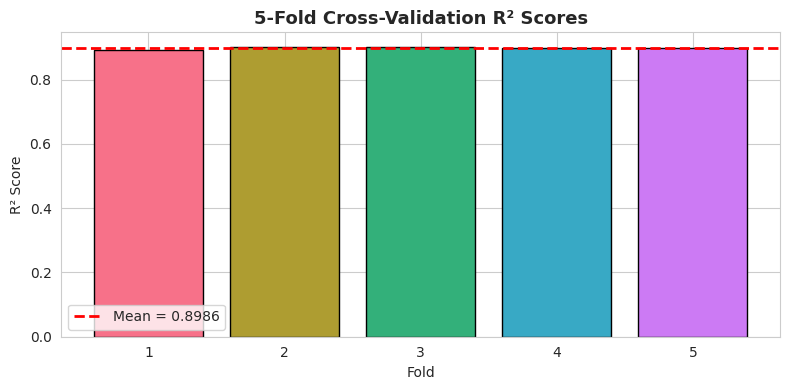

In [24]:
# Cross-Validation Report
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipe, X, y, cv=kf, scoring='r2')

print(f'5-Fold Cross-Validation R² for {best_name}:')
for fold, score in enumerate(cv_scores, 1):
    print(f'  Fold {fold}: {score:.4f}')
print(f'  Mean : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color=sns.color_palette('husl', 5), edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', lw=2, linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation R² Scores', fontsize=13, fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.legend()
plt.tight_layout()
plt.show()

### 🎛️ 9. Hyperparameter Tuning (GridSearchCV)

In [25]:
# Tune the best model  ─ adapt grid based on model type
if 'Random Forest' in best_name:
    param_grid = {
        'model__n_estimators':   [100, 200],
        'model__max_depth':      [None, 15, 25],
        'model__min_samples_split': [2, 5],
        'model__max_features':   ['sqrt', 'log2'],
    }
elif 'Gradient Boosting' in best_name:
    param_grid = {
        'model__n_estimators':   [100, 200],
        'model__max_depth':      [3, 5, 7],
        'model__learning_rate':  [0.05, 0.1],
        'model__subsample':      [0.8, 1.0],
    }
else:
    param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

print(f'Running GridSearchCV for: {best_name}')
print(f'Parameter grid: {param_grid}')

# Fresh pipeline for tuning
tune_pipe = Pipeline([('prep', preprocessor), ('model', trained_pipelines[best_name].named_steps['model'].__class__(random_state=42))])

grid_search = GridSearchCV(
    tune_pipe, param_grid,
    cv=3, scoring='r2',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n✅ Best Params : {grid_search.best_params_}')
print(f'   Best CV R²  : {grid_search.best_score_:.4f}')

Running GridSearchCV for: Random Forest
Parameter grid: {'model__n_estimators': [100, 200], 'model__max_depth': [None, 15, 25], 'model__min_samples_split': [2, 5], 'model__max_features': ['sqrt', 'log2']}
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Best Params : {'model__max_depth': 25, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 200}
   Best CV R²  : 0.8985


In [26]:
# Evaluate tuned model
tuned_pipe = grid_search.best_estimator_
y_pred_tuned_log = tuned_pipe.predict(X_test)
y_pred_tuned = np.expm1(y_pred_tuned_log)

tuned_r2   = r2_score(y_true_raw, y_pred_tuned)
tuned_mae  = mean_absolute_error(y_true_raw, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_tuned))

print(f'Tuned Model Performance:')
print(f'  R²   = {tuned_r2:.4f}  (before: {results_df.loc[best_name, "R2"]:.4f})')
print(f'  MAE  = ₹{tuned_mae:,.0f}  (before: ₹{results_df.loc[best_name, "MAE"]:,.0f})')
print(f'  RMSE = ₹{tuned_rmse:,.0f}  (before: ₹{results_df.loc[best_name, "RMSE"]:,.0f})')

Tuned Model Performance:
  R²   = 0.8629  (before: 0.8814)
  MAE  = ₹68,858  (before: ₹66,943)
  RMSE = ₹108,912  (before: ₹101,305)


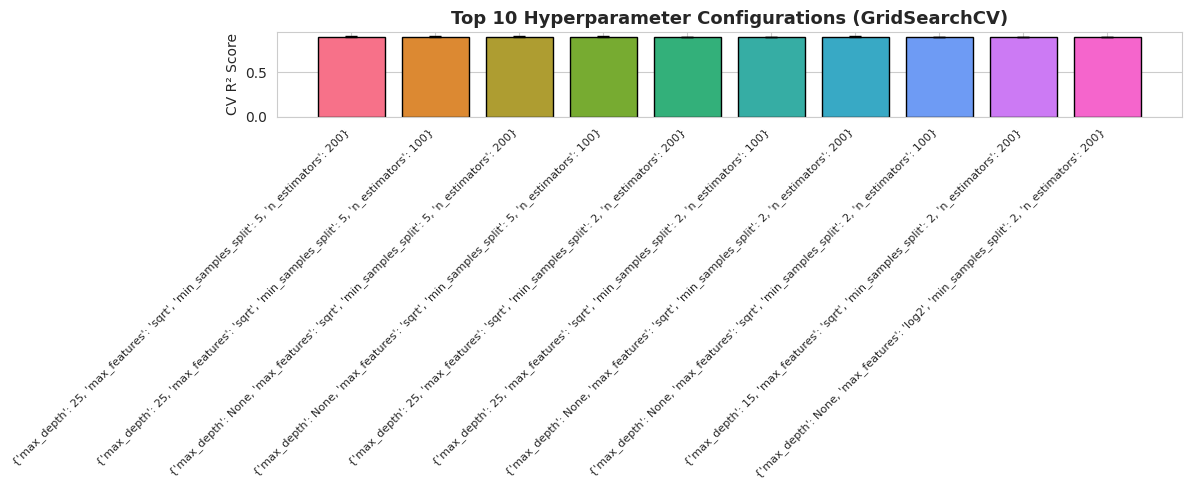

In [27]:
# GridSearch results visualisation — if more than 1 param
cv_results = pd.DataFrame(grid_search.cv_results_)
top_configs = cv_results.sort_values('mean_test_score', ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(range(len(top_configs)), top_configs['mean_test_score'],
        yerr=top_configs['std_test_score'],
        color=sns.color_palette('husl', 10), capsize=4, edgecolor='black')
plt.xticks(range(len(top_configs)),
           [str(p).replace("model__", "") for p in top_configs['params']], rotation=45, ha='right', fontsize=8)
plt.ylabel('CV R² Score')
plt.title('Top 10 Hyperparameter Configurations (GridSearchCV)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 💾 10. Save Model — Pickle File

In [28]:
# Save the final tuned pipeline AND metadata
model_artifact = {
    'pipeline'     : tuned_pipe,
    'features'     : FEATURES,
    'numeric_cols' : NUMERIC_COLS,
    'cat_cols'     : CAT_COLS,
    'test_r2'      : tuned_r2,
    'test_mae'     : tuned_mae,
    'model_name'   : best_name,
    'brand_list'   : df_model['brand'].unique().tolist(),
    'fuel_list'    : df_model['fuel'].unique().tolist(),
    'owner_list'   : df_model['owner'].unique().tolist(),
}

pkl_path = 'car_price_model.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(model_artifact, f)

size_kb = os.path.getsize(pkl_path) / 1024
print(f'✅ Model saved to "{pkl_path}"  ({size_kb:.1f} KB)')

# Verify load
with open(pkl_path, 'rb') as f:
    loaded = pickle.load(f)

test_pred = np.expm1(loaded['pipeline'].predict(X_test.head(3)))
print(f'🔄 Reload check — sample predictions: {test_pred.round(0).tolist()}')

✅ Model saved to "car_price_model.pkl"  (39475.3 KB)
🔄 Reload check — sample predictions: [174743.0, 116780.0, 392649.0]


### 🖥️ 11. Gradio Interface

In [29]:
import gradio as gr

# Load model from pickle
with open('car_price_model.pkl', 'rb') as f:
    artifact = pickle.load(f)

pipeline   = artifact['pipeline']
brand_list = sorted(artifact['brand_list'])
fuel_list  = sorted(artifact['fuel_list'])
owner_list = ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']


def predict_price(
    brand, km_driven, fuel, seller_type, transmission,
    owner, mileage, engine, max_power, seats, car_age
):
    try:
        input_df = pd.DataFrame([{
            'km_driven'   : float(km_driven),
            'fuel'        : fuel,
            'seller_type' : seller_type,
            'transmission': transmission,
            'owner'       : owner,
            'mileage'     : float(mileage),
            'engine'      : float(engine),
            'max_power'   : float(max_power),
            'seats'       : int(seats),
            'car_age'     : int(car_age),
            'brand'       : brand,
        }])

        log_pred = pipeline.predict(input_df)[0]
        price    = np.expm1(log_pred)

        # Confidence band ±12%
        low  = price * 0.88
        high = price * 1.12

        result = (
            f"🚗 Estimated Selling Price\n"
            f"{'─' * 35}\n"
            f"  💰 Predicted  : ₹ {price:>12,.0f}\n"
            f"  📉 Low Range  : ₹ {low:>12,.0f}\n"
            f"  📈 High Range : ₹ {high:>12,.0f}\n"
            f"{'─' * 35}\n"
            f"  Model : {artifact['model_name']}\n"
            f"  R²    : {artifact['test_r2']:.4f}"
        )
        return result

    except Exception as e:
        return f'⚠️ Error: {str(e)}'


# ── Gradio UI ──────────────────────────────────────────────
with gr.Blocks(
    title='🚗 Car Price Predictor',
    theme=gr.themes.Soft(primary_hue='blue')
) as demo:

    gr.Markdown("""
    # 🚗 Used Car Price Predictor
    ### Powered by Machine Learning · Dataset: Car Details v3
    Fill in the car details below and click **Predict Price** to get an instant estimate.
    """)

    with gr.Row():
        # ── Left Column: Car Identity
        with gr.Column(scale=1):
            gr.Markdown('### 🔖 Car Identity')
            brand        = gr.Dropdown(brand_list, label='Brand', value='Maruti')
            fuel         = gr.Radio(fuel_list, label='Fuel Type', value='Petrol')
            transmission = gr.Radio(['Manual', 'Automatic'], label='Transmission', value='Manual')
            seller_type  = gr.Radio(['Individual', 'Dealer', 'Trustmark Dealer'],
                                     label='Seller Type', value='Individual')
            owner        = gr.Dropdown(owner_list, label='Owner', value='First Owner')

        # ── Right Column: Specs
        with gr.Column(scale=1):
            gr.Markdown('### ⚙️ Car Specifications')
            car_age   = gr.Slider(1, 40, value=5, step=1, label='Car Age (years)')
            km_driven = gr.Number(value=50000, label='KM Driven')
            mileage   = gr.Slider(5.0, 35.0, value=18.0, step=0.1, label='Mileage (kmpl)')
            engine    = gr.Slider(500, 5000, value=1200, step=50, label='Engine (CC)')
            max_power = gr.Slider(30, 400, value=80, step=1, label='Max Power (bhp)')
            seats     = gr.Slider(2, 10, value=5, step=1, label='Seats')

    with gr.Row():
        predict_btn  = gr.Button('🚀 Predict Price', variant='primary', scale=2)
        clear_btn    = gr.Button('🔄 Reset', scale=1)

    output = gr.Textbox(label='Prediction Result', lines=9, )

    # Examples
    gr.Examples(
        examples=[
            ['Maruti',   50000,  'Petrol',  'Individual',      'Manual',    'First Owner',  22.0, 1200, 82,  5, 5],
            ['Honda',    30000,  'Petrol',  'Individual',      'Automatic', 'Second Owner', 17.0, 1500, 118, 5, 3],
            ['Toyota',   80000,  'Diesel',  'Dealer',          'Manual',    'First Owner',  21.0, 2000, 150, 7, 7],
            ['BMW',      40000,  'Petrol',  'Trustmark Dealer','Automatic', 'Second Owner', 12.0, 2000, 190, 5, 4],
            ['Mahindra', 120000, 'Diesel',  'Individual',      'Manual',    'Third Owner',  16.0, 2200, 130, 7, 10],
        ],
        inputs=[brand, km_driven, fuel, seller_type, transmission,
                owner, mileage, engine, max_power, seats, car_age],
        label='📋 Example Cars — Click to Auto-Fill'
    )

    gr.Markdown(f"""
    ---
    **Model Info:** {artifact['model_name']} · Test R² = {artifact['test_r2']:.4f} · MAE ≈ ₹{artifact['test_mae']:,.0f}
    """)

    predict_btn.click(
        fn=predict_price,
        inputs=[brand, km_driven, fuel, seller_type, transmission,
                owner, mileage, engine, max_power, seats, car_age],
        outputs=output
    )
    clear_btn.click(fn=lambda: None, outputs=output)


demo.launch(share=False, show_error=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [30]:
print('=' * 55)
print('  🚗 CAR PRICE PREDICTION — PIPELINE SUMMARY')
print('=' * 55)
print(f'  Dataset rows (raw)     : 8,128')
print(f'  Dataset rows (cleaned) : {len(df_clean):,}')
print(f'  Features used          : {len(FEATURES)}')
print(f'  Train / Test split     : 80% / 20%')
print()
print('  Models evaluated:')
for _, row in results_df.iterrows():
    marker = '  ★' if _ == best_name else '   '
    print(f'{marker} {_:<28} R² = {row["R2"]:.4f}')
print()
print(f'  Best model             : {best_name}')
print(f'  Tuned Test R²          : {tuned_r2:.4f}')
print(f'  Tuned Test MAE         : ₹{tuned_mae:,.0f}')
print(f'  Tuned Test RMSE        : ₹{tuned_rmse:,.0f}')
print()
print(f'  Pickle file            : car_price_model.pkl')
print(f'  Gradio interface       : ✅ Launched')
print('=' * 55)

  🚗 CAR PRICE PREDICTION — PIPELINE SUMMARY
  Dataset rows (raw)     : 8,128
  Dataset rows (cleaned) : 6,698
  Features used          : 11
  Train / Test split     : 80% / 20%

  Models evaluated:
  ★ Random Forest                R² = 0.8814
    Gradient Boosting            R² = 0.8695
    Ridge (L2)                   R² = 0.8507
    Linear Regression            R² = 0.8498
    ElasticNet (L1+L2)           R² = 0.8496
    Lasso (L1)                   R² = 0.8466
    Decision Tree                R² = 0.7919

  Best model             : Random Forest
  Tuned Test R²          : 0.8629
  Tuned Test MAE         : ₹68,858
  Tuned Test RMSE        : ₹108,912

  Pickle file            : car_price_model.pkl
  Gradio interface       : ✅ Launched
